# Example 1:(Simple) 
A teacher wants to divide her students into different groups. She has the marks scored by each student in an assignment, and based on these marks, she wants to segment them into groups.

In [3]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Student scores
scores = {
    'A': 10,
    'B': 7,
    'C': 28,
    'D': 20,
    'E': 35
}

students = list(scores.keys())

# Convert to DataFrame
df = pd.DataFrame({
    "student": students,
    "score": list(scores.values())
})

print(df)

  student  score
0       A     10
1       B      7
2       C     28
3       D     20
4       E     35


### Following shows steps on how the merge is done (Optional)

In [4]:
from scipy.spatial.distance import pdist, squareform

# Start with each student as its own cluster
clusters = [[s] for s in students]
values_map = {s: np.array([v]) for s, v in zip(students, scores.values())}

step = 1
while len(clusters) > 1:
    print(f"\n Step {step}:")
    
    # Compute pairwise distances
    dist_matrix = pd.DataFrame(index=[",".join(c) for c in clusters], columns=[",".join(c) for c in clusters])

    for i, ci in enumerate(clusters):
        for j, cj in enumerate(clusters):
            if i == j:
                dist_matrix.iloc[i, j] = 0
            elif pd.isnull(dist_matrix.iloc[i, j]):
                # Get all pairwise distances between elements in cluster ci and cj
                dists = [np.linalg.norm(values_map[si] - values_map[sj]) for si in ci for sj in cj]
                dist = np.min(dists)  # single linkage
                dist_matrix.iloc[i, j] = dist_matrix.iloc[j, i] = round(dist, 2)

    print("Distance Matrix:")
    print(dist_matrix)

    # Find the closest pair
    dist_matrix_vals = dist_matrix.replace(0, np.inf)
    min_dist = dist_matrix_vals.min().min()
    min_pos = np.where(dist_matrix_vals == min_dist)
    i, j = min_pos[0][0], min_pos[1][0]

    # Merge clusters
    new_cluster = clusters[i] + clusters[j]
    new_cluster.sort()
    print(f" Merging clusters: {clusters[i]} and {clusters[j]} (distance = {min_dist})")

    # Remove old clusters and add new
    clusters = [c for k, c in enumerate(clusters) if k != i and k != j]
    clusters.insert(0, new_cluster)

    step += 1



 Step 1:
Distance Matrix:
      A     B     C     D     E
A     0   3.0  18.0  10.0  25.0
B   3.0     0  21.0  13.0  28.0
C  18.0  21.0     0   8.0   7.0
D  10.0  13.0   8.0     0  15.0
E  25.0  28.0   7.0  15.0     0
 Merging clusters: ['A'] and ['B'] (distance = 3.0)

 Step 2:
Distance Matrix:
      A,B     C     D     E
A,B     0  18.0  10.0  25.0
C    18.0     0   8.0   7.0
D    10.0   8.0     0  15.0
E    25.0   7.0  15.0     0
 Merging clusters: ['C'] and ['E'] (distance = 7.0)

 Step 3:
Distance Matrix:
      C,E   A,B     D
C,E     0  18.0   8.0
A,B  18.0     0  10.0
D     8.0  10.0     0
 Merging clusters: ['C', 'E'] and ['D'] (distance = 8.0)

 Step 4:
Distance Matrix:
      C,D,E   A,B
C,D,E     0  10.0
A,B    10.0     0
 Merging clusters: ['C', 'D', 'E'] and ['A', 'B'] (distance = 10.0)


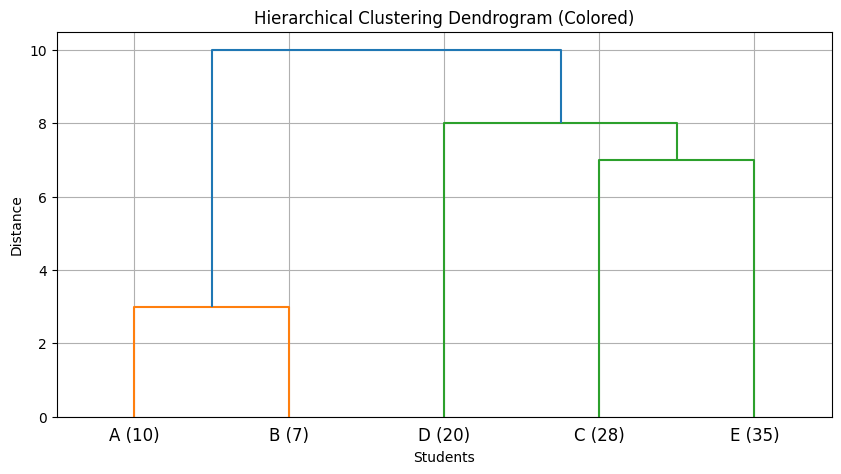

In [5]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Reuse the raw values for linkage-based dendrogram
X = np.array(list(scores.values())).reshape(-1, 1)
linked = linkage(X, method='single')

plt.figure(figsize=(10, 5))
dendrogram(linked,
           labels=[f"{k} ({v})" for k, v in scores.items()],
           color_threshold=9)
plt.title("Hierarchical Clustering Dendrogram (Colored)")
plt.xlabel("Students")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Now depending on how many groups we want, we can extract the group info from above by drawing a horizonatl line

# Example 2:(Simple) 
We read a CSV file that shows how many hours a week people spend on social media platforms and at the gym. We now want to know if there are clusters in this dataset and perform a Hierarchical Cluster Analysis.

In [6]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Convert to DataFrame
df = pd.read_csv('socialmedia_gym.csv')
print(df)

    Name  Social Media  Gym
0   Alan             7    3
1   Lisa             5    2
2    Joe             5    3
3    Max             7    4
4   Cora             4    5
5   Adam             8    9
6    Kim             2   12
7    Ali             8    2
8   Chen             4   14
9   Jack            14    1
10  Levi             8   10


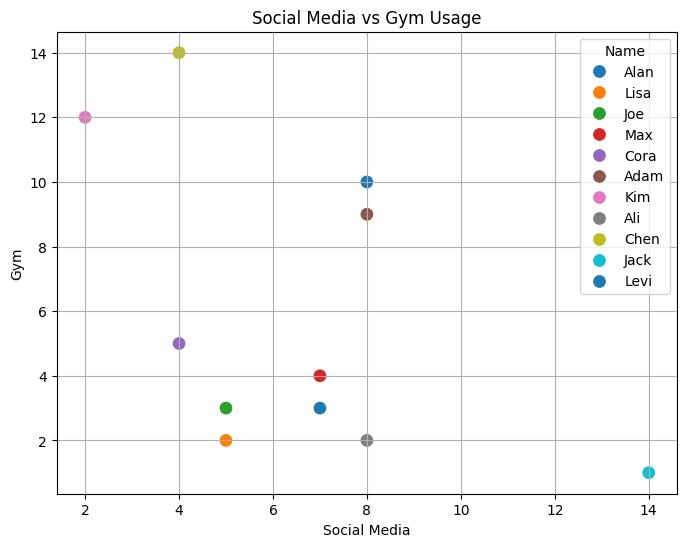

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Social Media", y="Gym", hue="Name", palette="tab10", s=100)

plt.title("Social Media vs Gym Usage")
plt.grid(True)
plt.show()

# Extract features
X = df[["Social Media", "Gym"]].values
names = df["Name"].tolist()

### following is optional

In [8]:
clusters = [[i] for i in range(len(X))]  # Cluster indices
cluster_names = [[name] for name in names]  # Cluster names for display

step = 1
while len(clusters) > 1:
    print(f"\n Step {step}:")
    
    labels = [",".join(name) for name in cluster_names]
    dist_matrix = pd.DataFrame(index=labels, columns=labels)
    
    for i in range(len(clusters)):
        for j in range(len(clusters)):
            if i == j:
                dist_matrix.iloc[i, j] = 0.0
            elif pd.isnull(dist_matrix.iloc[i, j]):
                # Compute min distance between two clusters (single linkage)
                dists = [np.linalg.norm(X[p1] - X[p2]) for p1 in clusters[i] for p2 in clusters[j]]
                dist = round(min(dists), 2)
                dist_matrix.iloc[i, j] = dist_matrix.iloc[j, i] = dist

    print("Distance Matrix:")
    print(dist_matrix)

    # Find closest pair to merge
    dist_vals = dist_matrix.replace(0, np.inf).astype(float)
    min_val = dist_vals.min().min()
    i, j = np.where(dist_vals == min_val)
    i, j = i[0], j[0]

    print(f" Merging: {cluster_names[i]} + {cluster_names[j]} (distance = {min_val})")

    # Merge clusters
    new_cluster = clusters[i] + clusters[j]
    new_name = cluster_names[i] + cluster_names[j]

    # Remove old clusters and insert new on top
    clusters = [c for k, c in enumerate(clusters) if k != i and k != j]
    cluster_names = [c for k, c in enumerate(cluster_names) if k != i and k != j]
    clusters.insert(0, new_cluster)
    cluster_names.insert(0, new_name)

    step += 1



 Step 1:
Distance Matrix:
      Alan   Lisa    Joe    Max   Cora  Adam    Kim    Ali   Chen   Jack  \
Alan   0.0   2.24    2.0    1.0   3.61  6.08   10.3   1.41   11.4   7.28   
Lisa  2.24    0.0    1.0   2.83   3.16  7.62  10.44    3.0  12.04   9.06   
Joe    2.0    1.0    0.0   2.24   2.24  6.71   9.49   3.16  11.05   9.22   
Max    1.0   2.83   2.24    0.0   3.16   5.1   9.43   2.24  10.44   7.62   
Cora  3.61   3.16   2.24   3.16    0.0  5.66   7.28    5.0    9.0  10.77   
Adam  6.08   7.62   6.71    5.1   5.66   0.0   6.71    7.0    6.4   10.0   
Kim   10.3  10.44   9.49   9.43   7.28  6.71    0.0  11.66   2.83  16.28   
Ali   1.41    3.0   3.16   2.24    5.0   7.0  11.66    0.0  12.65   6.08   
Chen  11.4  12.04  11.05  10.44    9.0   6.4   2.83  12.65    0.0   16.4   
Jack  7.28   9.06   9.22   7.62  10.77  10.0  16.28   6.08   16.4    0.0   
Levi  7.07   8.54   7.62   6.08    6.4   1.0   6.32    8.0   5.66  10.82   

       Levi  
Alan   7.07  
Lisa   8.54  
Joe    7.62  
Max 

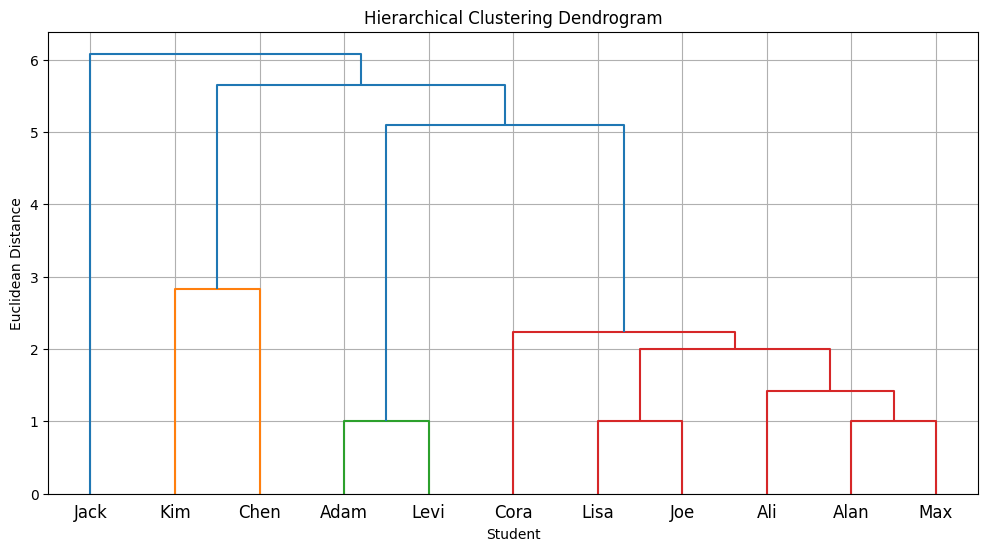

In [9]:
# Final Dendrogram
plt.figure(figsize=(12, 6))
linked = linkage(X, method='single', metric='euclidean')
dendrogram(linked, labels=names, orientation='top', distance_sort='ascending')
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Student")
plt.ylabel("Euclidean Distance")
plt.grid(True)
plt.show()

### "Are there clusters?" from the Dendrogram
Look at the vertical lines in the dendrogram:
- The height of each vertical line represents the distance (or dissimilarity) at which clusters are merged.
- A large vertical jump means very different clusters are being joined.

### How to interpret the dendrogram:
Look for a big gap in height near the top:

- This suggests a natural separation between clusters.
- Draw a horizontal line (threshold) just before the biggest jump to cut the dendrogram.
- Count how many vertical lines your horizontal cut crosses: That’s the number of clusters.

"The dendrogram shows a clear gap at distance X, suggesting the data naturally splits into 3 clusters. These clusters group people with similar patterns of social media and gym usage."